In [35]:
pip install peft

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [36]:
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import T5Tokenizer, T5ForConditionalGeneration
from torch.utils.data import DataLoader
import torch
from torch.utils.data import Dataset
from transformers import AdamW
from tqdm import tqdm
from sklearn.metrics import accuracy_score
from transformers import AutoTokenizer
from peft import get_peft_model, LoraConfig
import os


In [37]:
# Load WiC dataset from SuperGLUE
dataset = load_dataset("super_glue", "wic")

# Preprocessing function
def preprocess_wic(example):
    word = example["word"]
    sentence1 = example["sentence1"]
    sentence2 = example["sentence2"]
    label = example["label"]  # 1 for Yes, 0 for No

    # Reformatted input as per request
    inputs = f"Sentence 1: {sentence1} Sentence 2: {sentence2} Word: {word}"
    targets = "Yes" if label == 1 else "No"
    return {"input_text": inputs, "target_text": targets}


# Apply preprocessing to all splits
dataset = dataset.map(preprocess_wic)
# print("Example data from the training set:")
# print(dataset["train"].select(range(5)).to_pandas())  # Convert to pandas DataFrame for better visualization

In [38]:
# Load the T5 tokenizer and model
model_name = "t5-base"  # Or "t5-small", "t5-large"
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

# Define LoRA configuration
lora_config = LoraConfig(
    r=8,  # Rank of the adapter matrices
    lora_alpha=16,  # Scaling factor for LoRA
    target_modules=["q", "k", "v"],  # Modules to apply LoRA to
    lora_dropout=0.4501816446303697,  # Dropout for LoRA layers
)
# Apply LoRA to the model
model = get_peft_model(model, lora_config)

# Define a custom model wrapper with ReLU and save functionality
class T5WithReLU(torch.nn.Module):
    def __init__(self, t5_model):
        super().__init__()
        self.t5_model = t5_model
        self.relu = torch.nn.ReLU()

    def forward(self, input_ids, attention_mask=None, decoder_input_ids=None, labels=None):
        # Pass inputs through the original T5 model
        outputs = self.t5_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            decoder_input_ids=decoder_input_ids,
            labels=labels
        )
        logits = outputs.logits
        # Apply ReLU to the logits
        relu_logits = self.relu(logits)
        loss = None
        if labels is not None:
            # CrossEntropyLoss expects raw logits, so no ReLU for loss calculation
            loss_fn = torch.nn.CrossEntropyLoss(ignore_index=-100)
            loss = loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
        
        return {"loss": loss, "logits": relu_logits} if loss is not None else {"logits": relu_logits}

    # Delegate save_pretrained to the underlying T5 model
    def save_pretrained(self, save_directory):
        self.t5_model.save_pretrained(save_directory)

    def generate(self, *args, **kwargs):
        return self.t5_model.generate(*args, **kwargs)

# Wrap the model with the custom ReLU class
model = T5WithReLU(model)




spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [39]:
# Tokenization function
def tokenize_data(example):
    input_encodings = tokenizer(
        example["input_text"],
        max_length=128,
        padding="max_length",
        truncation=True,
    )
    target_encodings = tokenizer(
        example["target_text"],
        max_length=10,
        padding="max_length",
        truncation=True,
    )
    return {
        "input_ids": input_encodings["input_ids"],
        "attention_mask": input_encodings["attention_mask"],
        "labels": target_encodings["input_ids"],
    }

# Tokenize the dataset after preprocessing
tokenized_datasets = dataset.map(tokenize_data, batched=True)

Map:   0%|          | 0/5428 [00:00<?, ? examples/s]

Map:   0%|          | 0/638 [00:00<?, ? examples/s]

Map:   0%|          | 0/1400 [00:00<?, ? examples/s]

In [40]:
# Convert to PyTorch dataset
train_dataset = tokenized_datasets["train"].with_format("torch")
valid_dataset = tokenized_datasets["validation"].with_format("torch")
test_dataset = tokenized_datasets["test"].with_format("torch")

# DataLoader for batching
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [41]:
class CustomTestDataset(Dataset):
    def __init__(self, input_file, label_file, tokenizer, max_length=128):
        # Load input data
        with open(input_file, "r") as f:
            self.inputs = [line.strip() for line in f.readlines()]

        # Load labels
        with open(label_file, "r") as f:
            self.labels = [1 if line.strip() == "T" else 0 for line in f.readlines()]

        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        # Extract input and label for the current index
        input_text = self.inputs[idx]
        label = self.labels[idx]

        # Tokenize the input text
        encodings = self.tokenizer(
            input_text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        return {
            "input_ids": encodings["input_ids"].squeeze(0),  # Remove batch dimension
            "attention_mask": encodings["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }

In [42]:
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("t5-base")

# Create the test dataset
test_dataset = CustomTestDataset(
    input_file="/kaggle/input/test-data/test/formatted_data.txt",
    label_file="/kaggle/input/test-data/test/test.gold.txt",
    tokenizer=tokenizer
)

# Create the DataLoader for batching
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Inspect a batch
for batch in test_loader:
    print(batch)
    break

{'input_ids': tensor([[7142,  536,   10,  ...,    0,    0,    0],
        [7142,  536,   10,  ...,    0,    0,    0],
        [7142,  536,   10,  ...,    0,    0,    0],
        ...,
        [7142,  536,   10,  ...,    0,    0,    0],
        [7142,  536,   10,  ...,    0,    0,    0],
        [7142,  536,   10,  ...,    0,    0,    0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]]), 'labels': tensor([1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0])}


In [43]:
# Optimizer
optimizer = AdamW(model.parameters(), lr=9.762477675627743e-5)
num_epochs = 20

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#print(device)
model.to(device)

T5WithReLU(
  (t5_model): PeftModel(
    (base_model): LoraModel(
      (model): T5ForConditionalGeneration(
        (shared): Embedding(32128, 768)
        (encoder): T5Stack(
          (embed_tokens): Embedding(32128, 768)
          (block): ModuleList(
            (0): T5Block(
              (layer): ModuleList(
                (0): T5LayerSelfAttention(
                  (SelfAttention): T5Attention(
                    (q): lora.Linear(
                      (base_layer): Linear(in_features=768, out_features=768, bias=False)
                      (lora_dropout): ModuleDict(
                        (default): Dropout(p=0.4501816446303697, inplace=False)
                      )
                      (lora_A): ModuleDict(
                        (default): Linear(in_features=768, out_features=8, bias=False)
                      )
                      (lora_B): ModuleDict(
                        (default): Linear(in_features=8, out_features=768, bias=False)
                      )


In [44]:
# Initialize lists to store loss and accuracy values
train_losses = []
train_accuracies = []  # List to store training accuracy
val_losses = []  # List to store validation loss
val_accuracies = []  # List to store validation accuracy


actual_epochs=0
# Early stopping variables
patience_epochs = 3  # Number of epochs to wait for improvement in validation loss
best_val_loss = float('inf')  # Initialize with a very large number
epochs_without_improvement = 0  # Counter for epochs without improvement

# Training loop
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    correct_train_preds = 0  # Counter for correct predictions in training
    total_train_tokens = 0  # Counter for total tokens (or samples for classification tasks)
    actual_epochs+=1

    for batch in tqdm(train_loader):
        optimizer.zero_grad()

        # Move inputs to GPU if available
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs["loss"]  # Access the loss key in the dictionary
        train_loss += loss.item()

        # Get predictions and compare with labels
        logits = outputs["logits"]
        predicted_labels = torch.argmax(logits, dim=-1)  # Get the predicted labels

        # Flatten tensors to compare predictions and labels token-wise
        predicted_labels_flat = predicted_labels.view(-1)
        labels_flat = labels.view(-1)

        # Mask padding tokens if necessary (assume -100 is the ignore index for padding)
        mask = labels_flat != -100
        correct_train_preds += (predicted_labels_flat[mask] == labels_flat[mask]).sum().item()
        total_train_tokens += mask.sum().item()

        # Backward pass
        loss.backward()
        optimizer.step()

    # Calculate average training loss
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Calculate training accuracy
    train_accuracy = correct_train_preds / total_train_tokens  # Normalize by total tokens
    train_accuracies.append(train_accuracy)
    
    print(f"Epoch {epoch + 1}, Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy * 100:.2f}%")

    # Validation
    model.eval()
    val_loss = 0
    correct_val_preds = 0
    total_val_tokens = 0  # Counter for total validation tokens
    predictions = []
    references = []

    for batch in tqdm(valid_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs["loss"]
        val_loss += loss.item()

        logits = outputs["logits"]
        predicted_labels = torch.argmax(logits, dim=-1)  # Get the predicted label

        # Flatten tensors to compare predictions and labels token-wise
        predicted_labels_flat = predicted_labels.view(-1)
        labels_flat = labels.view(-1)

        # Mask padding tokens if necessary
        mask = labels_flat != -100
        correct_val_preds += (predicted_labels_flat[mask] == labels_flat[mask]).sum().item()
        total_val_tokens += mask.sum().item()

        decoded_preds = tokenizer.batch_decode(predicted_labels, skip_special_tokens=True)
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

        predictions.extend(decoded_preds)
        references.extend(decoded_labels)

    # Calculate average validation loss
    avg_val_loss = val_loss / len(valid_loader)
    val_losses.append(avg_val_loss)

    # Calculate validation accuracy
    val_accuracy = correct_val_preds / total_val_tokens  # Normalize by total tokens
    val_accuracies.append(val_accuracy)
    
    print(f"Epoch {epoch + 1}, Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy * 100:.2f}%")

    # Check if validation loss improved
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
        # Save the model with the best validation loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Validation loss improved. Saving model to 'best_model.pth'")
    else:
        epochs_without_improvement += 1

    # If no improvement for 'patience_epochs' epochs, stop training
    if epochs_without_improvement >= patience_epochs:
        print(f"Early stopping. Validation loss did not improve for {patience_epochs} epochs.")
        break


100%|██████████| 340/340 [02:05<00:00,  2.71it/s]


Epoch 1, Training Loss: 3.8949, Training Accuracy: 79.78%


100%|██████████| 40/40 [00:06<00:00,  5.77it/s]


Epoch 1, Validation Loss: 0.1874, Validation Accuracy: 80.00%
Validation loss improved. Saving model to 'best_model.pth'


100%|██████████| 340/340 [02:04<00:00,  2.74it/s]


...

Epoch 7, Validation Loss: 0.0803, Validation Accuracy: 80.17%


100%|██████████| 340/340 [02:04<00:00,  2.74it/s]


Epoch 8, Training Loss: 0.0759, Training Accuracy: 81.58%


100%|██████████| 40/40 [00:06<00:00,  5.76it/s]

Epoch 8, Validation Loss: 0.0779, Validation Accuracy: 80.03%
Early stopping. Validation loss did not improve for 3 epochs.


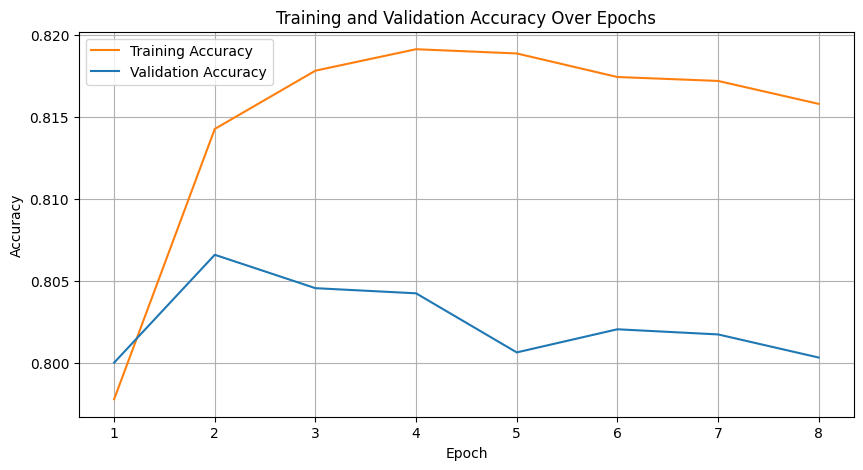

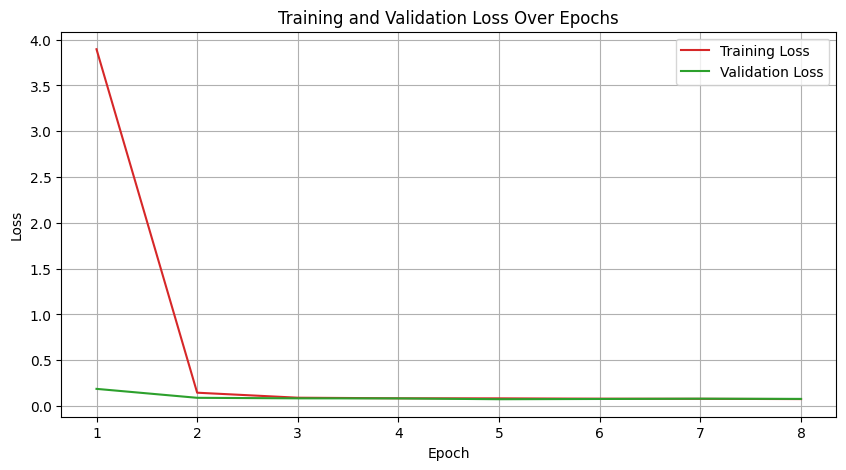

In [45]:
# Plotting both training and validation accuracies on the same curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, actual_epochs + 1), train_accuracies, color='tab:orange', label='Training Accuracy')
plt.plot(range(1, actual_epochs + 1), val_accuracies, color='tab:blue', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("Training and Validation Accuracy Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

# Plotting both training and validation losses on the same curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, actual_epochs + 1), train_losses, color='tab:red', label='Training Loss')
plt.plot(range(1, actual_epochs + 1), val_losses, color='tab:green', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Training and Validation Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
# Save the model and tokenizer
#model.save_pretrained("t5-lora")
#tokenizer.save_pretrained("t5-lora")

In [47]:
# # Load the saved model and tokenizer
# model_dir = '/kaggle/working/t5-lora'
# tokenizer = T5Tokenizer.from_pretrained(model_dir)
# model = T5ForConditionalGeneration.from_pretrained(model_dir)

# # Set the device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)
# model.eval() 

In [48]:
def predict(input_text):
    # Tokenize the input text
    inputs = tokenizer(input_text, return_tensors="pt", padding="max_length", max_length=128, truncation=True)
    input_ids = inputs.input_ids.to(device)
    attention_mask = inputs.attention_mask.to(device)

    # Generate predictions
    with torch.no_grad():
        outputs = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_length=2)
    predicted_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return predicted_text

In [49]:
test_file_path = '/kaggle/input/test-data/test/formatted_data.txt'
gold_file_path = '/kaggle/input/test-data/test/test.gold.txt'  # Gold labels file path
output_file_path = '/kaggle/working/predictions.txt'

In [50]:
output_dir = os.path.dirname(output_file_path)
if not os.path.exists(output_dir):
    os.makedirs(output_dir)  # Create the directory if it doesn't exist

In [51]:
with open(test_file_path, 'r', encoding='utf-8') as f:
    test_data = f.readlines()

with open(gold_file_path, 'r', encoding='utf-8') as f:
    gold_labels = [line.strip() for line in f.readlines()]  # Read gold labels

# Ensure test data and gold labels are of the same length
assert len(test_data) == len(gold_labels), "Test data and gold labels must have the same number of lines."

# Running predictions on test data, saving to file, and calculating accuracy
correct_predictions = 0
total_predictions = len(test_data)

with open(output_file_path, 'w', encoding='utf-8') as output_file:
    for i, text in enumerate(test_data):
        text = text.strip()  # Remove any extra whitespace
        if text:  # Skip empty lines
            prediction = predict(text)
            # Convert "Fal" to "F" and "True" to "T"
            if prediction == "Fal":
                prediction = "F"
            elif prediction == "True":
                prediction = "T"
            gold_label = gold_labels[i]
            
            # Save each prediction to file
            output_file.write(prediction + '\n')
            
            # Check if the prediction matches the gold label
            if prediction == gold_label:
                correct_predictions += 1

# Calculate accuracy
accuracy = correct_predictions / total_predictions * 100
print(f"Predictions saved to {output_file_path}")
print(f"Model Accuracy: {accuracy:.2f}%")

Predictions saved to /kaggle/working/predictions.txt
Model Accuracy: 65.71%


### Error Analysis

In [ ]:
# Function to paraphrase a sentence
def paraphrase(sentence, num_return_sequences=1, num_beams=5):
    input_text = f"paraphrase: {sentence} </s>"
    input_ids = tokenizer.encode(input_text, return_tensors="pt", truncation=True).to(device)  # Move input to GPU
    outputs = model.generate(
        input_ids,
        max_length=128,
        num_beams=num_beams,
        num_return_sequences=num_return_sequences,
        early_stopping=True
    )
    return [tokenizer.decode(output, skip_special_tokens=True) for output in outputs]

# Load the dataset from the file
input_file = "./WiC_dataset_processed/train/formatted_data.txt"
output_file = "augmented_data.txt"

# Read the dataset with the appropriate encoding
with open(input_file, "r", encoding="utf-8") as file:
    lines = file.readlines()

# Process the dataset with a progress bar
augmented_data = []
for line in tqdm(lines, desc="Processing lines", unit="line"):
    if line.strip():  # Ignore empty lines
        parts = line.split("word:")  # Split the line into sentences and target word
        sentences = parts[0].strip()
        word = parts[1].strip()
        sentence1, sentence2 = sentences.split("sentence2:")
        sentence1 = sentence1.replace("sentence1:", "").strip()
        sentence2 = sentence2.strip()

        # Generate paraphrases
        paraphrased_s1 = paraphrase(sentence1)[0]
        paraphrased_s2 = paraphrase(sentence2)[0]

        # Create the augmented line
        augmented_line = f"sentence1: {paraphrased_s1} sentence2: {paraphrased_s2} word: {word}\n"
        augmented_data.append(augmented_line)

# Save the augmented dataset
with open(output_file, "w", encoding="utf-8") as file:
    file.writelines(augmented_data)

print(f"Augmented dataset saved to {output_file}")


### CLean the augmented dataset

In [ ]:
input_file = "augmented_data.txt"  # Your input file
output_file = "cleaned_data.txt"  # File to save the cleaned data

def clean_and_filter_lines(input_file, output_file):
    cleaned_lines = []
    with open(input_file, "r", encoding="utf-8") as infile:
        for line in infile:
            if line.strip():  # Skip empty lines
                parts = line.split("word:")  # Split the line into sentences and word
                if len(parts) == 2:  # Ensure the line is correctly formatted
                    sentences, word = parts
                    sentence1_part = sentences.split("sentence2:")
                    if len(sentence1_part) == 2:  # Ensure both sentence1 and sentence2 exist
                        sentence1 = sentence1_part[0].replace("sentence1:", "").strip().replace("Paraphrase:", "").strip()
                        sentence2 = sentence1_part[1].strip().replace("Paraphrase:", "").strip()
                        word = word.strip()

                        # Check if the sentences are meaningful (not "False" or empty)
                        if sentence1 and sentence2 and sentence1.lower() != "false" and sentence2.lower() != "false":
                            cleaned_line = f"sentence1: {sentence1} sentence2: {sentence2} word: {word}\n"
                            cleaned_lines.append(cleaned_line)

    # Save the cleaned lines to a new file
    with open(output_file, "w", encoding="utf-8") as outfile:
        outfile.writelines(cleaned_lines)

    print(f"Cleaned data saved to {output_file}")

# Run the cleaning function
clean_and_filter_lines(input_file, output_file)
